In [1]:
import mdtraj as md
import os
import glob
import pandas as pd
from metfish.utils import get_Pr
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
plt.rcParams.update({
    'font.size': 8,            # Default font size
    'axes.labelsize': 9,       # Axis title size
    'axes.titlesize': 9,       
    'xtick.labelsize': 8,      # X tick labels
    'ytick.labelsize': 8,      # Y tick labels
    'legend.fontsize': 8,      # Legend
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans', 'Liberation Sans', 'sans-serif'],# Use Arial or Helvetica
    'pdf.fonttype': 42         # Editable text in PDFs
})

In [4]:
output_path='/global/cfs/cdirs/m4704/100125_Nature_Com_data/results/NMR_rename'

In [5]:
ref_path='/global/cfs/cdirs/m4704/100125_Nature_Com_data/Apo_holo_data/pdbs'

In [6]:
openfold_path='/global/cfs/cdirs/m4704/100125_Nature_Com_data/results/AF_rename'

In [7]:
# Calculate the SAXS difference of two curves
def l1_loss_padded(y_true, y_pred, pad_value=0):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    len_true = y_true.shape[0]
    len_pred = y_pred.shape[0]
    
    if len_true < len_pred:
        y_true = np.pad(y_true, (0, len_pred - len_true), constant_values=pad_value)
    elif len_pred < len_true:
        y_pred = np.pad(y_pred, (0, len_true - len_pred), constant_values=pad_value)
    return np.sum(np.abs(y_true - y_pred))

def l1_loss_calculation(target_path, ref_path):
    ref_saxs=get_Pr(ref_path, None, None, 0.5)
    target_saxs=get_Pr(target_path, None, None, 0.5)
    return l1_loss_padded(ref_saxs[1],target_saxs[1])

In [8]:
# Compare the RMSD of the test with the ref structure
def generate_rmsd_alphaSAXS(pdb_id,ref_path,output_path,pdb_id_ref=None):
    if not pdb_id_ref:
        pdb_id_ref=pdb_id
    rmsd=[]
    ref_t=md.load(os.path.join(ref_path,pdb_id_ref+'.pdb'))
    ref_atom=ref_t.topology.select('name CA')
    test_t = md.load(os.path.join(output_path, pdb_id+'.pdb'))
    test_atom=test_t.topology.select('name CA')
    if len(test_atom)!=len(ref_atom):
        return pdb_id+' has the wrong length'
    ca_selection=md.rmsd(test_t,ref_t,0,test_atom,ref_atom)
    return ca_selection[0]*10

In [9]:
# Check the sequence length
def check_seq_length(pdb_id, ref_path, output_path):
    # --- Load Reference ---
    ref_t = md.load(os.path.join(ref_path, pdb_id + '.pdb'))
    ref_atom_indices = ref_t.topology.select('name CA')
    
    # Convert CA atom indices to a 1-letter sequence string (e.g., "MKT...")
    ref_seq_list = [ref_t.topology.atom(i).residue.code for i in ref_atom_indices]
    ref_seq = "".join(ref_seq_list)
    ref_len = len(ref_seq)

    # --- Load Test ---
    test_t = md.load(os.path.join(output_path, pdb_id + '.pdb'))
    test_atom_indices = test_t.topology.select('name CA')
    
    # Convert CA atom indices to a 1-letter sequence string
    test_seq_list = [test_t.topology.atom(i).residue.code for i in test_atom_indices]
    test_seq = "".join(test_seq_list)
    test_len = len(test_seq)

    # --- Return Results ---
    # Returns a tuple: (Reference Sequence, Test Sequence, Reference Length, Test Length)
    return [ref_seq, test_seq, ref_len, test_len]

In [10]:
pdb_list=[ f[:-4] for f in os.listdir(ref_path) if f.endswith('.pdb')]
len(pdb_list)

80

In [11]:
result={}
result_openfold={}
seq_length={}
for i in pdb_list:
    result[i]=generate_rmsd_alphaSAXS(i,ref_path,output_path)
    result_openfold[i]=generate_rmsd_alphaSAXS(i,ref_path,openfold_path)
    #seq_length[i]=check_seq_length(i,ref_path,openfold_path)

In [12]:
#seq_length

In [13]:
def self_join_pair(target_dict):
    pair_csv=pd.read_csv('/global/cfs/cdirs/m4704/100125_Nature_Com_data/Apo_holo_data/Table_rmsd_Apo_vs_Holo.csv',sep=';')
    pair_dict={}
    for index, i in pair_csv.iterrows():
        pair_dict[i['Apo_ID']]=i['Holo_ID']
    result_csv=pd.DataFrame.from_dict(target_dict,orient='index').reset_index().rename(columns={'index':'ID',0:'Value'})
    result_csv['pair_ID']=result_csv['ID'].map(pair_dict)
    return result_csv, result_csv.dropna().merge(result_csv[['ID',
'Value']],left_on='pair_ID',right_on='ID',suffixes=['','_pair']).drop(columns={'pair_ID'})

In [14]:
rmsd_df, rmsd_pair= self_join_pair(result)
rmsd_openfold_df, rmsd_openfold_pair= self_join_pair(result_openfold)

In [15]:
rmsd_pair['type']='RMSD'
rmsd_openfold_pair['type']='RMSD'
rmsd_pair['model']='AlphaSAXS'
rmsd_openfold_pair['model']='OpenFold'

In [21]:
pair_df=pd.concat([rmsd_pair,rmsd_openfold_pair])

In [22]:
pair_df

,ID,Value,ID_pair,Value_pair,type,model
0,1XSA-23_A,3.966835,1XSC-20_A,2.489262,RMSD,AlphaSAXS
1,1K2H-4_A,6.283178,1ZFS-13_B,2.555465,RMSD,AlphaSAXS
2,2D9E-12_A,3.527607,2RS9-13_B,3.458194,RMSD,AlphaSAXS
3,1EX6_B,3.097864,1EX7_A,2.172379,RMSD,AlphaSAXS
4,2AI6-18_A,2.770106,2OZW-3_A,3.577565,RMSD,AlphaSAXS
...,...,...,...,...,...,...
35,1SYM-2_B,5.831723,1XYD-15_B,1.908022,RMSD,OpenFold
36,2JU3-3_A,3.030244,2JU8-9_A,1.799868,RMSD,OpenFold
37,1LMZ-9_A,3.400153,1P7M-18_A,2.276325,RMSD,OpenFold
38,2CJO-5_A,1.477864,1ROE-10_A,4.440145,RMSD,OpenFold


In [23]:
def Pr_div(row,root_path):
    return l1_loss_calculation(os.path.join(root_path,row['ID']+'.pdb'),os.path.join(root_path,row['ID_pair']+'.pdb'))

In [24]:
def RMSD_div(row,root_path):
    return generate_rmsd_alphaSAXS(row['ID'],root_path,root_path,row['ID_pair'])

In [25]:
def calculate_pr_div(row):
    # This logic handles the conditional root_path if needed inside the function
    if row['model'] == 'OpenFold':
        root_path = openfold_path
    elif row['model'] == 'AlphaSAXS':
        root_path = output_path
    else:
        root_path = default_path # Add a default case if necessary

    # Call your original function with the row and path
    return Pr_div(row, root_path)

def calculate_rmsd_div(row):
    # Same conditional path logic here
    if row['model'] == 'OpenFold':
        root_path = openfold_path
    elif row['model'] == 'AlphaSAXS':
        root_path = output_path
    else:
        root_path = default_path
        
    return RMSD_div(row, root_path)  

In [26]:
pair_df[pair_df['ID']=='1JFJ-3_A']

,ID,Value,ID_pair,Value_pair,type,model
15,1JFJ-3_A,9.334153,1JFK_A,10.838048,RMSD,AlphaSAXS
15,1JFJ-3_A,13.630023,1JFK_A,13.271120,RMSD,OpenFold


In [27]:
generate_rmsd_alphaSAXS('1JFJ-3_A',output_path,output_path,'1JFK_A')

3.9517638087272644

In [28]:
pair_df[pair_df['ID']=='1JFJ-3_A'].apply(calculate_rmsd_div, axis=1)

15    3.951764
15    1.133325
dtype: float64

In [29]:
pair_df['P(r) Div'] = pair_df.apply(calculate_pr_div, axis=1)
pair_df['RMSD Div'] = pair_df.apply(calculate_rmsd_div, axis=1)
pair_df['Ref P(r) Div'] = pair_df.apply(Pr_div, axis=1,args=(ref_path,))
pair_df['Ref RMSD Div'] = pair_df.apply(RMSD_div, axis=1,args=(ref_path,))

/global/homes/l/lemonboy/.local/perlmutter/python-3.11/lib/python3.11/site-packages/Bio/PDB/PDBParser.py:384: PDBConstructionWarning: Ignoring unrecognized record 'END' at line 1220
  warnings.warn(
/global/homes/l/lemonboy/.local/perlmutter/python-3.11/lib/python3.11/site-packages/Bio/PDB/PDBParser.py:384: PDBConstructionWarning: Ignoring unrecognized record 'END' at line 1220
  warnings.warn(
/global/homes/l/lemonboy/.local/perlmutter/python-3.11/lib/python3.11/site-packages/Bio/PDB/PDBParser.py:384: PDBConstructionWarning: Ignoring unrecognized record 'END' at line 735
  warnings.warn(
/global/homes/l/lemonboy/.local/perlmutter/python-3.11/lib/python3.11/site-packages/Bio/PDB/PDBParser.py:384: PDBConstructionWarning: Ignoring unrecognized record 'END' at line 735
  warnings.warn(
/global/homes/l/lemonboy/.local/perlmutter/python-3.11/lib/python3.11/site-packages/Bio/PDB/PDBParser.py:384: PDBConstructionWarning: Ignoring unrecognized record 'END' at line 971
  warnings.warn(
/global/

In [30]:
pair_df.columns

Index(['ID', 'Value', 'ID_pair', 'Value_pair', 'type', 'model', 'P(r) Div',
       'RMSD Div', 'Ref P(r) Div', 'Ref RMSD Div'],
      dtype='object')

In [49]:
conditions = [
    (pair_df['Ref P(r) Div'] <= 0.05),

    (pair_df['Ref P(r) Div']  > 0.05) & (pair_df['Ref P(r) Div'] <= 0.1),

    (pair_df['Ref P(r) Div']  > 0.1)
]

choices = ['High', 'Medium', 'Low']

pair_df['Apo vs Holo Similarity'] = np.select(
    conditions, 
    choices,
)

In [50]:
pair_df['Apo vs Holo Similarity']

0     Medium
1     Medium
2     Medium
3        Low
4       High
       ...  
35    Medium
36       Low
37    Medium
38      High
39      High
Name: Apo vs Holo Similarity, Length: 80, dtype: object

In [51]:
pair_df[pair_df['model']=='AlphaSAXS'].describe()

,Value,Value_pair,P(r) Div,RMSD Div,Ref P(r) Div,Ref RMSD Div
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,4.790562,4.317596,0.014272,0.591899,0.100604,4.842308
std,4.129779,4.303178,0.022515,0.820734,0.101900,2.148813
min,1.486535,1.054575,0.005180,0.126332,0.016368,2.078363
25%,2.663962,2.104610,0.006670,0.219907,0.043143,3.299209
50%,3.626485,2.771363,0.009281,0.332417,0.069274,4.556831
75%,4.699488,4.305283,0.013143,0.524348,0.114983,5.520036
max,19.080915,18.458424,0.147975,3.951764,0.554710,14.726907


In [52]:
pair_df[pair_df['model']=='OpenFold'].describe()

,Value,Value_pair,P(r) Div,RMSD Div,Ref P(r) Div,Ref RMSD Div
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,5.010425,4.252404,0.007048,0.428535,0.100604,4.842308
std,4.709924,5.041146,0.007188,0.773541,0.101900,2.148813
min,0.931586,0.433919,0.001749,0.023663,0.016368,2.078363
25%,2.630206,1.883875,0.003398,0.042843,0.043143,3.299209
50%,3.408131,2.888778,0.004460,0.075883,0.069274,4.556831
75%,5.056472,4.016751,0.007468,0.487600,0.114983,5.520036
max,21.210043,22.532883,0.041981,4.050386,0.554710,14.726907


In [53]:
pair_df.columns

Index(['ID', 'Value', 'ID_pair', 'Value_pair', 'type', 'model', 'P(r) Div',
       'RMSD Div', 'Ref P(r) Div', 'Ref RMSD Div', 'Apo vs Holo Similarity'],
      dtype='object')

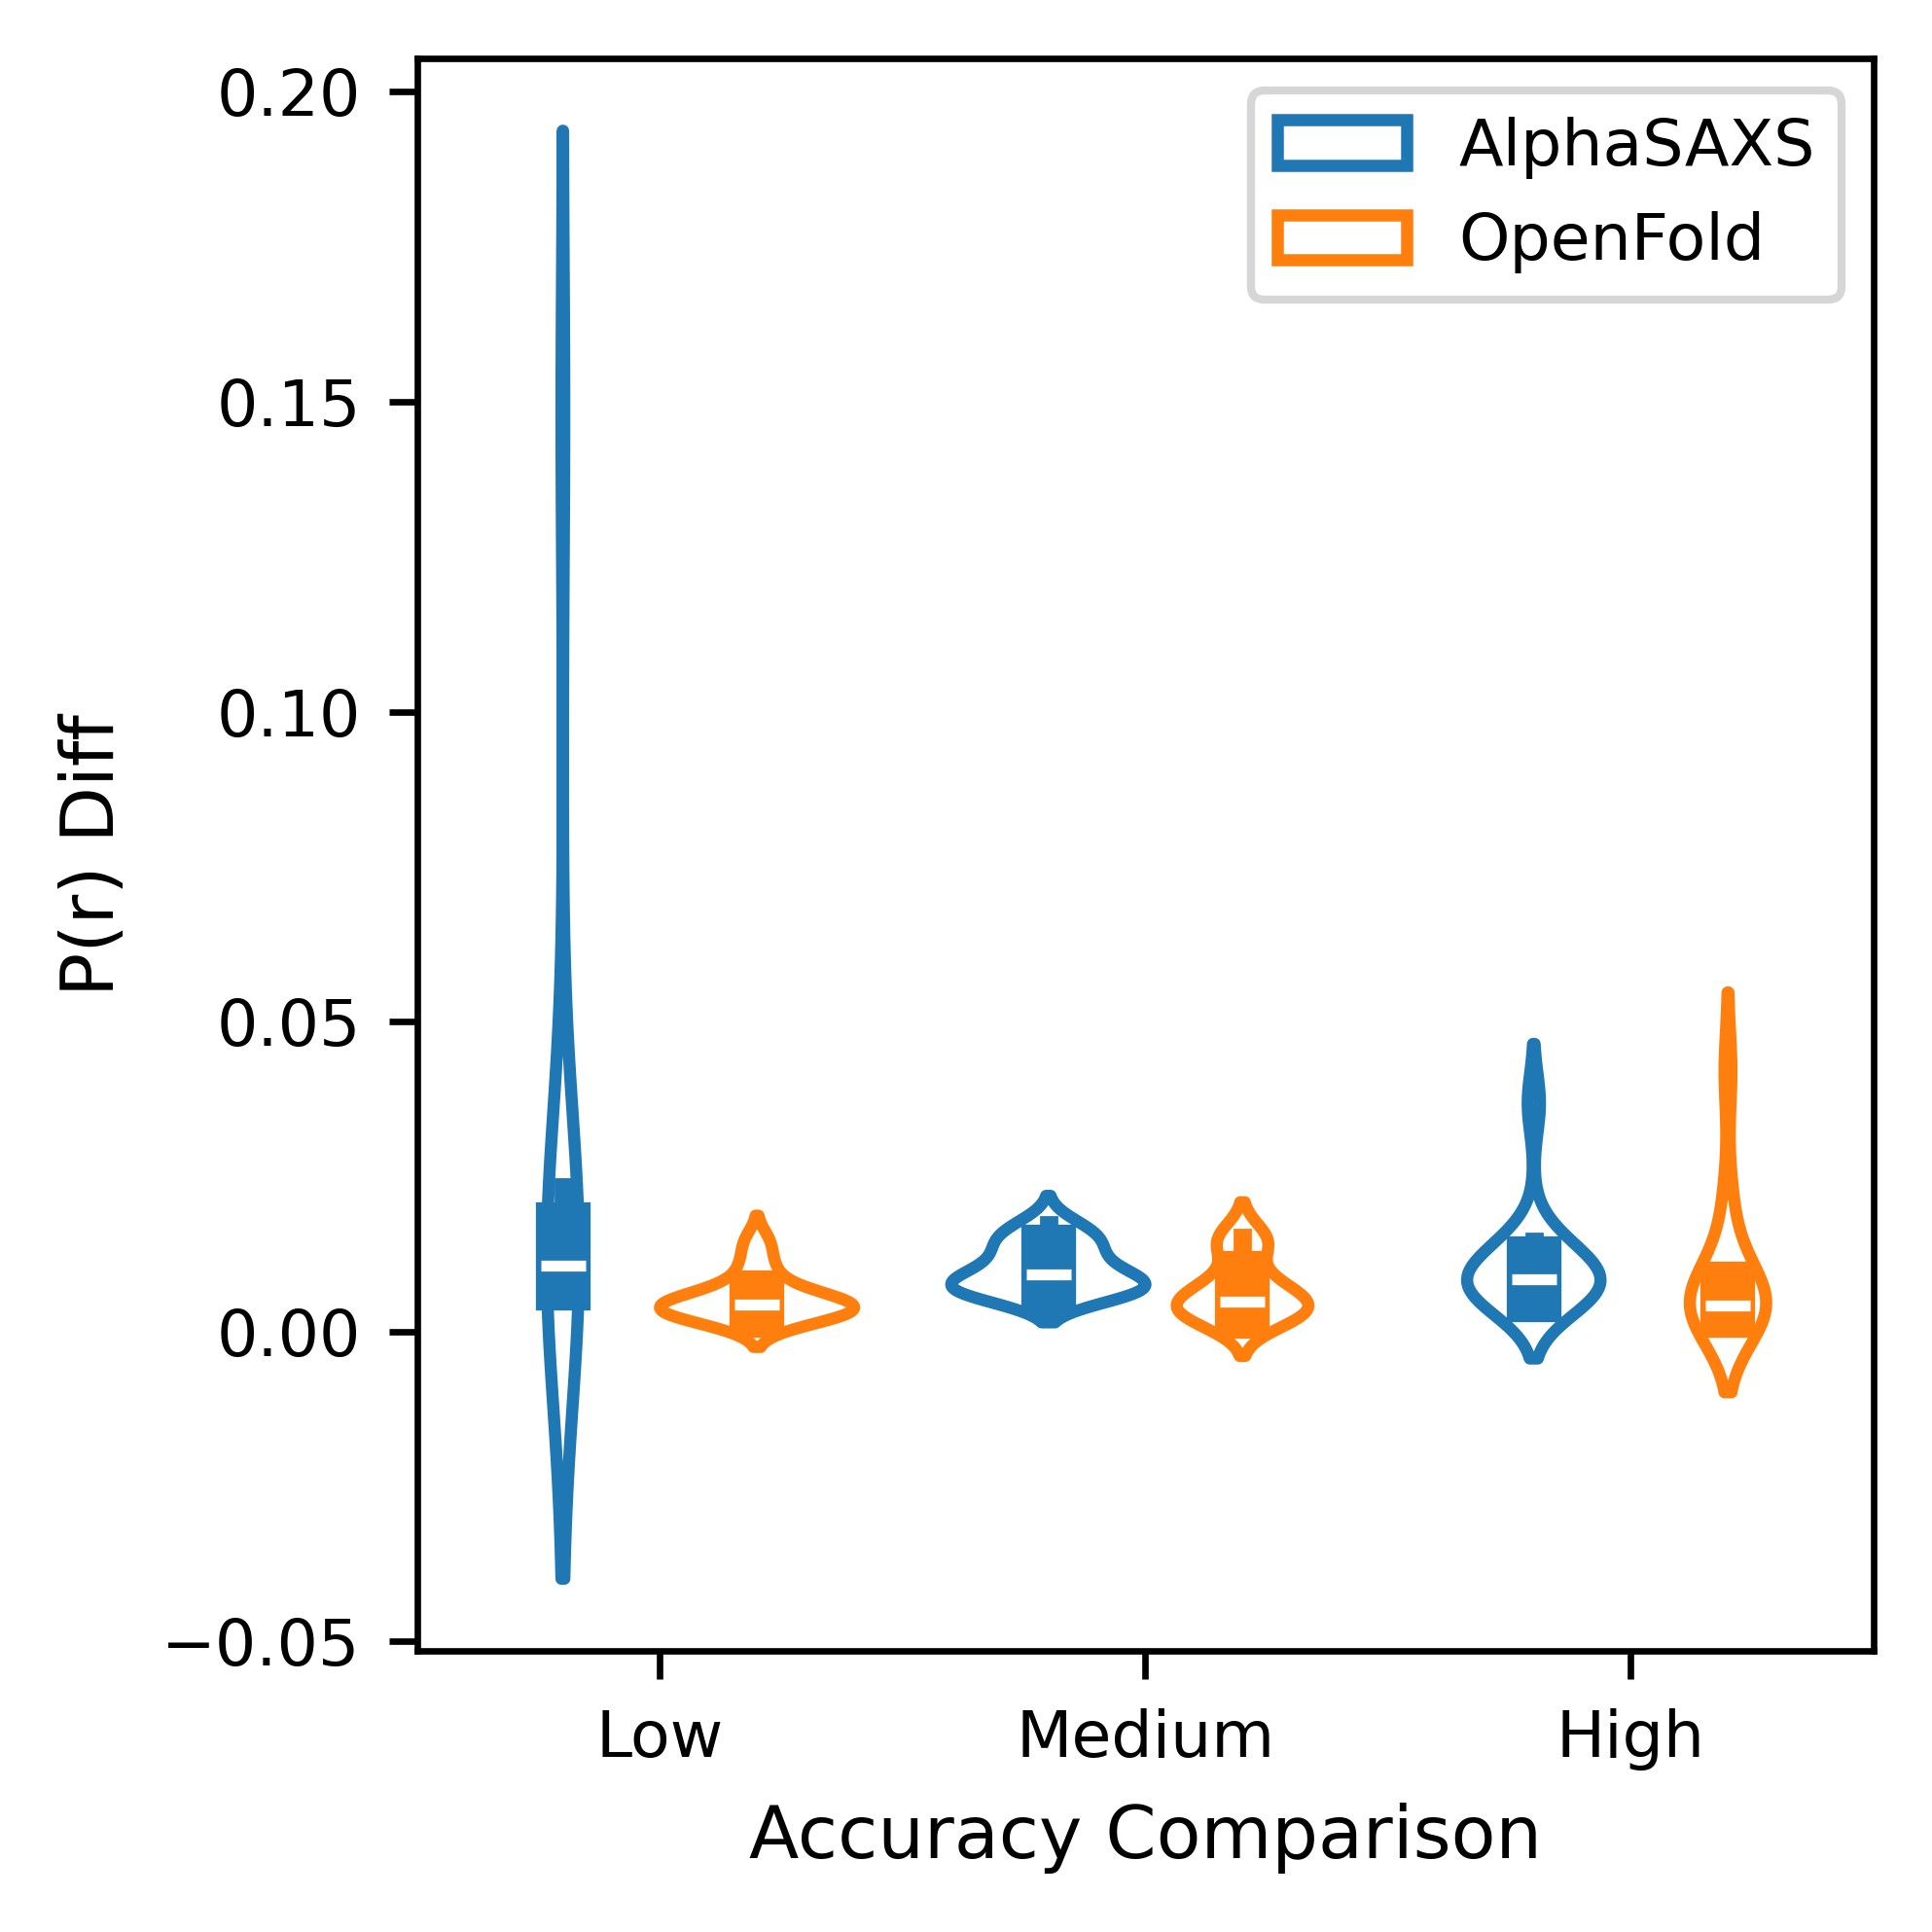

In [55]:
fig, ax = plt.subplots(figsize=(3.35, 3.35), dpi=600) # Single-column, high-res

sns.violinplot(y='P(r) Div',x='Apo vs Holo Similarity',hue='model',fill=False, data=pair_df, ax=ax,order=['Low', 'Medium', 'High'])
ax.set_xlabel('Accuracy Comparison', labelpad=4)
ax.set_ylabel('P(r) Diff', labelpad=4)
#ax.set_title('Violin Plot Example', fontsize=9, pad=8)

# Remove legend if it just duplicates x info, or set title to None
legend = ax.get_legend()
if legend:
    legend.set_title(None)

plt.tight_layout()

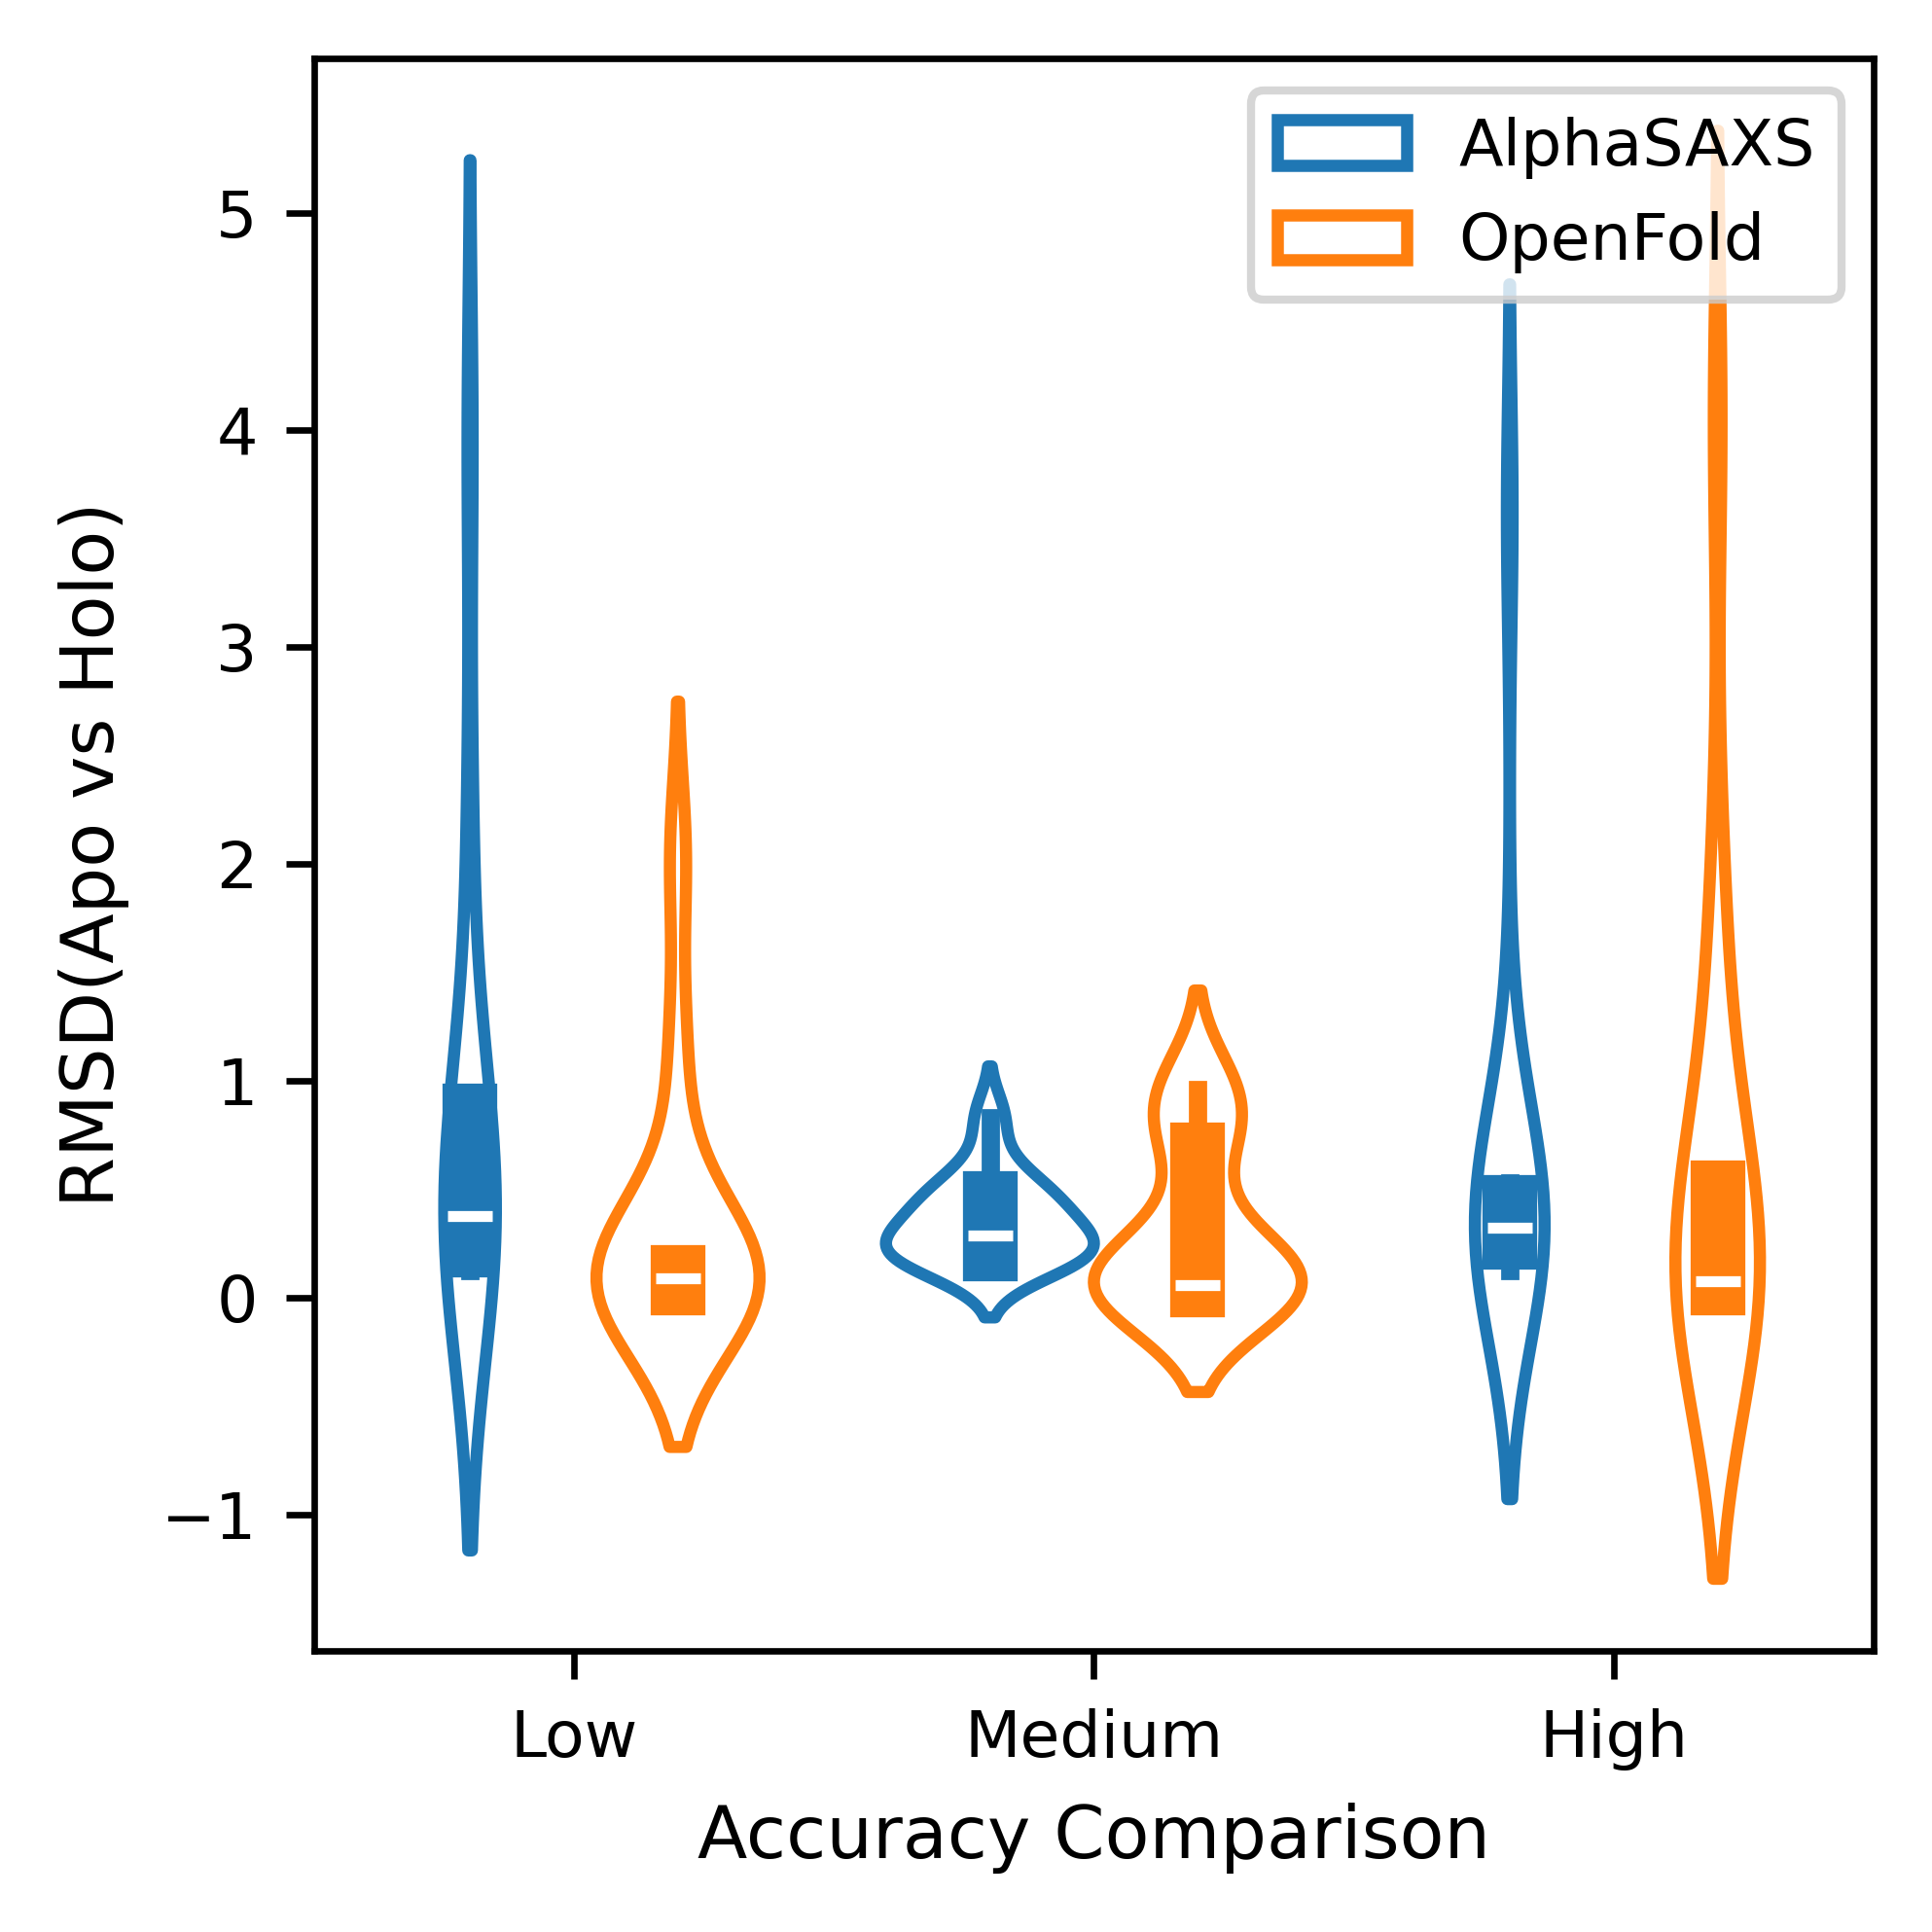

In [57]:
fig, ax = plt.subplots(figsize=(3.35, 3.35), dpi=600) # Single-column, high-res

sns.violinplot(y='RMSD Div',x='Apo vs Holo Similarity',hue='model',fill=False, data=pair_df, ax=ax,order=['Low', 'Medium', 'High'])
ax.set_xlabel('Accuracy Comparison', labelpad=4)
ax.set_ylabel('RMSD(Apo vs Holo)', labelpad=4)
#ax.set_title('Violin Plot Example', fontsize=9, pad=8)

# Remove legend if it just duplicates x info, or set title to None
legend = ax.get_legend()
if legend:
    legend.set_title(None)

plt.tight_layout()

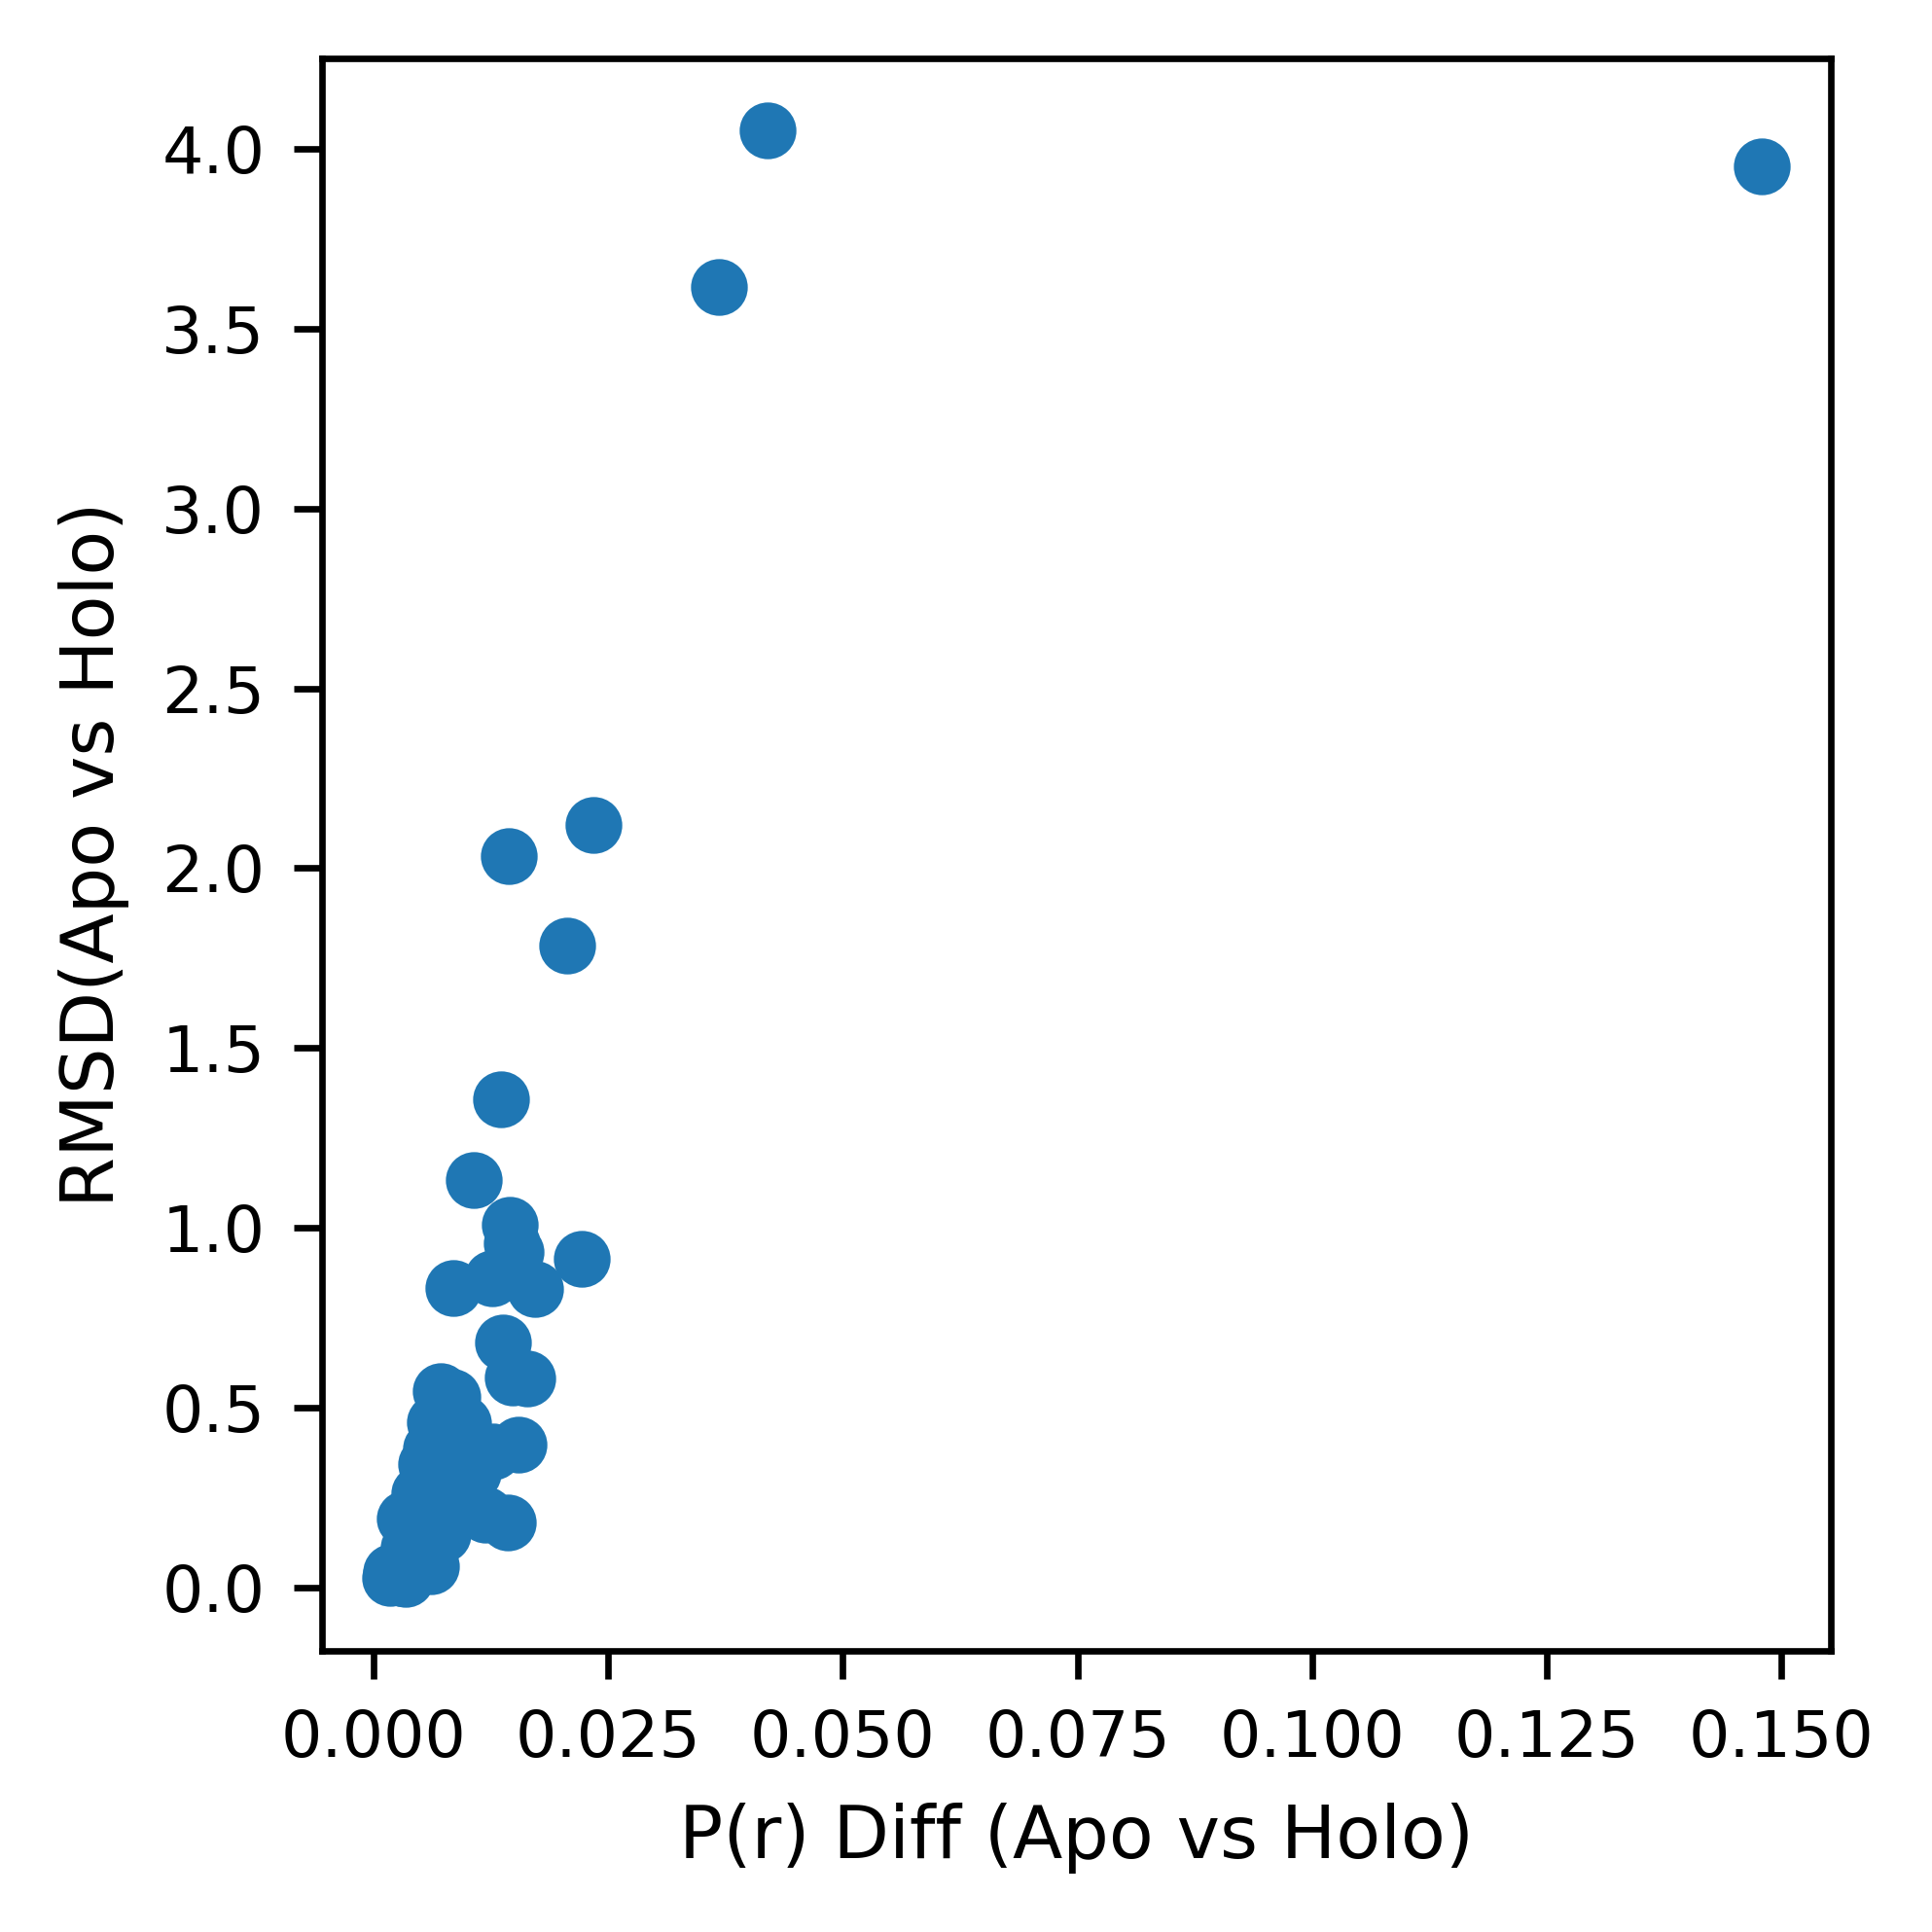

In [58]:
fig, ax = plt.subplots(figsize=(3.35, 3.35), dpi=600) # Single-column, high-res

plt.scatter(y='RMSD Div',x='P(r) Div', data=pair_df)
ax.set_xlabel('P(r) Diff (Apo vs Holo)', labelpad=4)
ax.set_ylabel('RMSD(Apo vs Holo)', labelpad=4)
#ax.set_title('Violin Plot Example', fontsize=9, pad=8)

# Remove legend if it just duplicates x info, or set title to None
legend = ax.get_legend()
if legend:
    legend.set_title(None)

plt.tight_layout()

In [59]:
import numpy as np
from scipy import stats

pearson_coef, p_value = stats.pearsonr(pair_df[pair_df['model']=='AlphaSAXS']['Ref P(r) Div'], pair_df[pair_df['model']=='AlphaSAXS']['P(r) Div'])

# Print the results
print(f"Pearson Correlation Coefficient: {pearson_coef:.4f}")
print(f"P-value: {p_value:.4f}")

Pearson Correlation Coefficient: 0.7404
P-value: 0.0000
